In [38]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

Use the file heights_weights.csv which contains 10000 non-null values for heights and weights. The Male column shows 1 if the
person is a Male and 0 if the person is a Female. Take file of dataset from:
https://raw.githubusercontent.com/kavit88/Data-Sets/main/heights_weights.csv
1. Convert this file into a pandas Data Frame.
2. Display basic information like memory and data types for this data frame.
3. Display basic statistics like mean, std, quartiles, etc. for this data frame.
4. Create a correlation table for the data frame and comment about what kind ofcorrelation is there between Height and
Weight.
5. Do Height and Weight contain any outliers? Answer by creating boxplots for both.
6. Finally, create a scatter plot of Weight v/s Height with the following specifications

In [39]:
df = pd.read_csv("https://raw.githubusercontent.com/kavit88/Data-Sets/main/heights_weights.csv")

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Height  10000 non-null  float64
 1   Weight  10000 non-null  float64
 2   Male    10000 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 234.5 KB


In [41]:
df.describe()

,Height,Weight,Male
count,10000.000000,10000.000000,10000.000000
mean,66.367560,161.440357,0.500000
std,3.847528,32.108439,0.500025
min,54.263133,64.700127,0.000000
25%,63.505620,135.818051,0.000000
50%,66.318070,161.212928,0.500000
75%,69.174262,187.169525,1.000000
max,78.998742,269.989698,1.000000


In [42]:
df.corr(numeric_only=True)

,Height,Weight,Male
Height,1.000000,0.924756,0.691072
Weight,0.924756,1.000000,0.796723
Male,0.691072,0.796723,1.000000


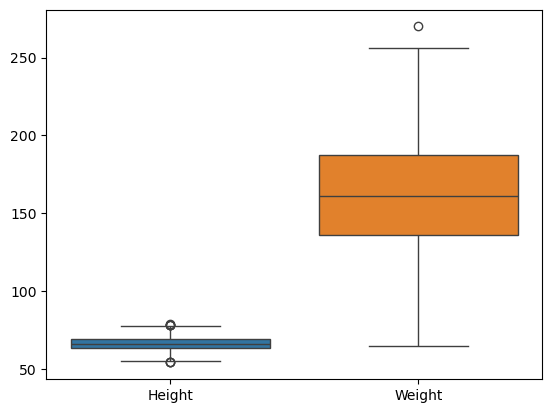

In [43]:
sns.boxplot(df[['Height','Weight']])
plt.show()

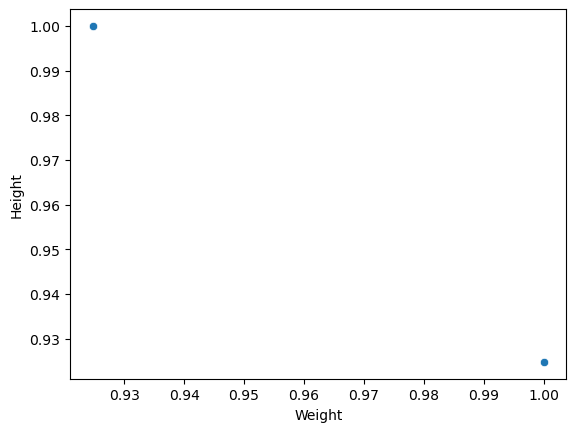

In [44]:
sns.scatterplot(data = df[['Height','Weight']].corr(numeric_only=True),x='Weight',y="Height")
plt.show()

Using ‘supermarket_sales.csv’ file do the following operations and give required answer by using proper programming process.
1). Load the dataset into a pandas DataFrame and read first 8 rows.
2). Check for missing values and fill it by mean values of that particular column if any.
3). Find the number of orders which have ‘Quantity’ less than 3 and which have (either ‘Rating’ greater than 8.5 or ‘Total’
greater than 600).
4). Find the sum of ‘Total’ purchasing price spent by Member and Normal 'Customer type'.
5). Find the percentage of total of ‘gross income’ based on the different ‘Payment’ methods used by customers. (Ewallet, Cash
and Credit card)
6). Analyze the purchasing behavior of male and female customers using ‘Gender’ column. Find their average purchase prices
using ‘Total’ column.
7). Create a scatter plot that shows the relationship between total amount spent and rating.
8). Create a box plot that shows the distribution of ‘Rating’ and ‘Quantity’. And comment about outliers in both columns.
9). Visualize with parallel co-ordinates for ‘Unit price’, ‘Total’, ’cogs’ columns’ data with respect to ‘Product line'

In [45]:
df = pd.read_csv('/home/shlok/College/SemIV/FCSP2/02-visualization/supermarket_sales.csv')

In [46]:
df.fillna(value=df.mean(numeric_only=True),inplace=True)

In [47]:
df

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,01-05-2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,03-08-2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,03-03-2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,02-08-2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,13:46,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,03-02-2019,17:16,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,02-09-2019,13:22,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,15:33,Cash,65.82,4.761905,3.2910,4.1


In [48]:
df.groupby('Customer type')['Total'].sum()

Customer type
Member    164223.444
Normal    158743.305
Name: Total, dtype: float64

In [51]:
df1 = df.groupby('Payment')['gross income'].sum()
total = df['gross income'].sum()
per = (df1/total*100)
print(per)

Payment
Cash           34.742453
Credit card    31.200448
Ewallet        34.057099
Name: gross income, dtype: float64


In [57]:
df.groupby('Gender')['Total'].agg(['mean'])

,mean
Gender,
Female,335.095659
Male,310.789226


<Axes: xlabel='Rating', ylabel='Total'>

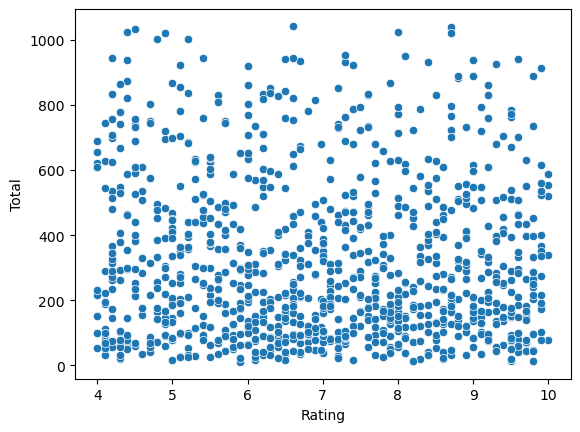

In [62]:
sns.scatterplot(data=df,y='Total',x='Rating')

<Axes: xlabel='Rating'>

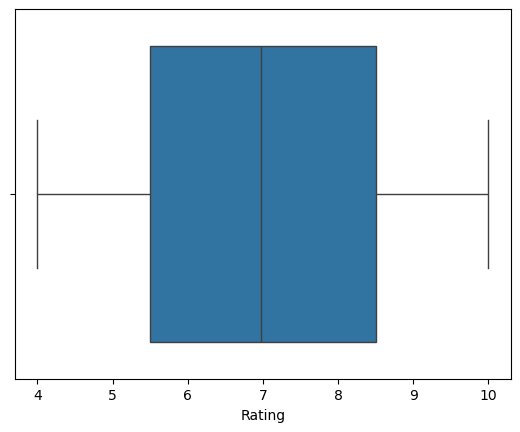

In [64]:
sns.boxplot(data=df,x='Rating')

<Axes: >

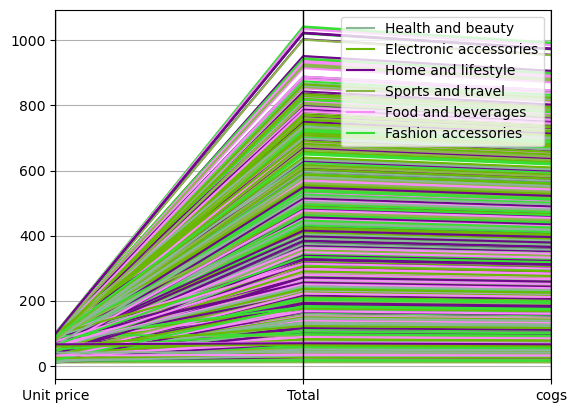

In [68]:
pd.plotting.parallel_coordinates(df[['Product line','Unit price','Total','cogs']],class_column='Product line')

array([[<Axes: xlabel='Unit price', ylabel='Unit price'>,
        <Axes: xlabel='Total', ylabel='Unit price'>,
        <Axes: xlabel='cogs', ylabel='Unit price'>],
       [<Axes: xlabel='Unit price', ylabel='Total'>,
        <Axes: xlabel='Total', ylabel='Total'>,
        <Axes: xlabel='cogs', ylabel='Total'>],
       [<Axes: xlabel='Unit price', ylabel='cogs'>,
        <Axes: xlabel='Total', ylabel='cogs'>,
        <Axes: xlabel='cogs', ylabel='cogs'>]], dtype=object)

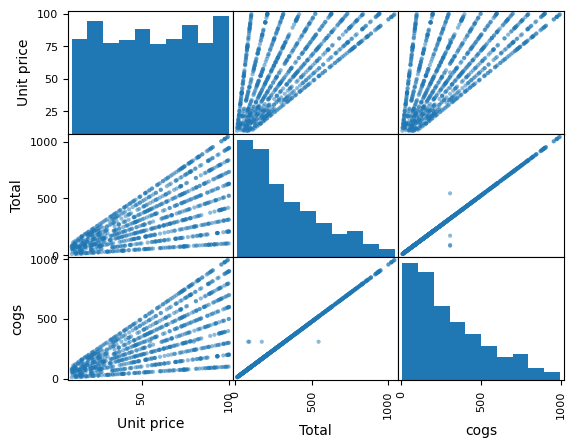

In [69]:
pd.plotting.scatter_matrix(df[['Product line','Unit price','Total','cogs']])

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  